In [ ]:
from graph_transformer_long_range_niches.tl import pad_batch
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, FIG_PATH, LEGNINI23
from graph_transformer_long_range_niches.model import LitGNNTransformer
from graph_transformer_long_range_niches.pl import CustomColormap, plot_attention_sender_receiver, plot_attention_sender_receiver, SelfAttentionRelevance, calculate_attention, normalized_attention, normalized_class_attention
from graph_transformer_long_range_niches.pp import prepare_geome_dataset, split_adata
from graph_transformer_long_range_niches.config import load_config

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle

import scanpy as sc
import squidpy as sq
from scipy.sparse import issparse

from sklearn.preprocessing import MinMaxScaler

In [ ]:
FOLDER = "legnini23"
GEX_DATA = "legnini23_None_sample_1_44"
CSV_PATH = Path(RESULTS, FOLDER, f"{GEX_DATA}_obs.csv")

In [ ]:
def load_model(PATH, model_type = "gnn-transformer", RESULTS = RESULTS, FOLDER = FOLDER):
    model_transformer_ckpt = torch.load(Path(RESULTS, FOLDER, f"{PATH}_{model_type}.ckpt"))
    cfg = model_transformer_ckpt['hyper_parameters']['cfg']
    model_transformer = LitGNNTransformer(model_transformer_ckpt['hyper_parameters']['cfg'])
    model_transformer.load_state_dict(model_transformer_ckpt['state_dict'])
    # obs_csv = pd.read_csv(Path(RESULTS, FOLDER, f"{PATH}_obs.csv"))
    # obs_csv = obs_csv.rename(columns={'Unnamed: 0': 'obs_names'})
    return model_transformer, cfg

In [ ]:
def prepare_data(DATA_PATH, CSV_PATH):
    adata = sc.read_h5ad(Path(DATA_PATH))
    obs_csv = pd.read_csv(Path(CSV_PATH))
    if 'obs_names' in adata.obs:
        adata.obs = adata.obs.rename(columns={'obs_names': 'obs_names_orig'})
        obs_csv = obs_csv.rename(columns={'obs_names': 'obs_names_orig'})
    obs_csv = obs_csv.rename(columns={'Unnamed: 0': 'obs_names'})
    adata.obs['split'] = np.array(obs_csv['split'].values)
    adata.obs['obs_names'] = np.array(obs_csv['obs_names'].values)
    return adata, obs_csv

# Evaluation: Legnini et. al, 2023

Legnini, I., Emmenegger, L., Zappulo, A. et al. Spatiotemporal, optogenetic control of gene expression in organoids. Nat Methods 20, 1544–1552 (2023). https://doi.org/10.1038/s41592-023-01986-w

## Load the model checkpoint and data

In [5]:
model_transformer_gex, cfg_gex = load_model(GEX_DATA, model_type = "gnn-transformer")

num features: 88


In [6]:
adata, obs_csv = prepare_data(LEGNINI23, CSV_PATH)

In [7]:
np.unique(adata.obs['Area'])

array([   718.,    748.,    760., ..., 119634., 177522., 185347.])

In [7]:
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'sample', 'condition', 'organoid']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition  organoid   
train  slide1_D2-2  SHH        organoid #2    4318
       slide1_D2-3  SHH        organoid #4    3621
val    slide1_C2-2  SHH        organoid #2    3510
train  slide4_B2-1  SHH        organoid #2    3345
       slide1_B2-1  SHH        organoid #2    3299
val    slide1_A2-1  SHH        organoid #2    3023
train  slide1_C2-1  Ctrl       organoid #5    2870
       slide4_A2-1  SHH        organoid #2    2630
       slide4_A2-2  SHH        organoid #1    2506
val    slide1_B2-3  SHH        organoid #4    2241
test   slide4_A2-3  Ctrl       organoid #5    1984
val    slide1_C2-5  Ctrl       organoid #8    1958
test   slide4_B2-2  SHH        organoid #3    1779
train  slide1_B2-2  Ctrl       organoid #6    1701
       slide1_A2-2  SHH        organoid #4    1694
       slide4_B2-3  Ctrl       organoid #7    1643
       slide1_C2-3  Ctrl       organoid #7    1640
Name: count, dtype: int64


Q: Is the only covariate the condition or are the sample slices also different in other aspects???

## Inference 

### SHH Class 

Can we identify the SHH pathway influence by attention classification on the SHH class?

In [8]:
adata.X = adata.layers['log1p_norm']

In [9]:
# Identify SHH center
shh_threshold = 3.7

shh_values = adata[:, 'SHH'].X
# If sparse, convert to dense
if issparse(shh_values):
    shh_values = shh_values.toarray()
# Ensure it's a 1D array
shh_values = shh_values.flatten()

adata.obs['shh_cluster'] = np.where(shh_values < shh_threshold, str(0), str(1))
obs_csv['shh_cluster'] = np.where(shh_values < shh_threshold, str(0), str(1))

In [10]:
adata.obs['shh_cluster'][adata.obs['sample'] == 'slide1_A2-1'].astype(int).sum()

2

In [11]:
#sub_adata_ctrl, attention_matrix_dict_ctrl, trans_in_dict_ctrl, trans_out_dict_ctrl = calculate_attention(adata, cfg_gex, model_transformer_gex, attn_obs = 'shh_cluster', attn_class = '1', obs_col = 'sample', class_name = 'slide4_A2-3', library_key=None)
#sub_adata_shh, attention_matrix_dict_shh, trans_in_dict_shh, trans_out_dict_shh = calculate_attention(adata, cfg_gex, model_transformer_gex, attn_obs = 'shh_cluster', attn_class = '1', obs_col = 'sample', class_name ='slide4_B2-2', library_key=None)
sub_adata_shh, attention_matrix_dict_shh, trans_in_dict_shh, trans_out_dict_shh = calculate_attention(adata, cfg_gex, model_transformer_gex, obs_col = 'sample', class_name = 'slide1_A2-1', library_key=None)

call new
call new
DataBatch(x=[3023, 88], edge_index=[2, 10], obs_names=[3023], batch=[3023], ptr=[2]) None
Category mask:  torch.Size([2001, 1, 128])
2001
Layer 1 attention gradient shape: torch.Size([4, 2001, 2001])
Layer 1 attention output weights shape: torch.Size([4, 2001, 2001])
Average attention map shape: torch.Size([2001, 2001])
I:  tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])
Layer 2 attention gradient shape: torch.Size([4, 2001, 2001])
Layer 2 attention output weights shape: torch.Size([4, 2001, 2001])
Average attention map shape: torch.Size([2001, 2001])
I:  tensor([[1.0000e+00, 2.4499e-07, 9.6010e-07,  ..., 4.2599e-07, 7.8323e-07,
         3.9694e-07],
        [1.4770e-11, 1.0000e+00, 0.0000e+00,  ..., 9.4973e-13, 3.1336e-11,
         1.1900e-12],
        [0.0000e+00,

None


ValueError: ('Lengths must match to compare', (1999,), (1,))

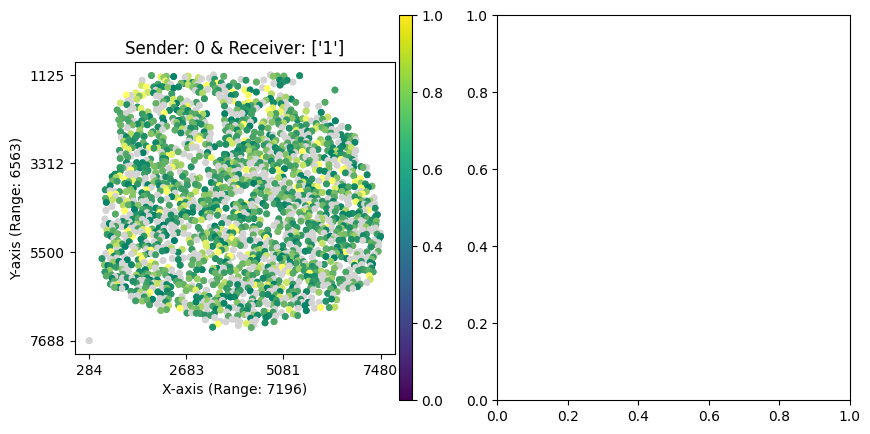

In [14]:
sender = '0'
receiver = ['1']
class_name = 'shh_cluster'

attn_matrix_dict = attention_matrix_dict_shh
sub_adata = sub_adata_shh

for library_id in attn_matrix_dict.keys():
    print(library_id)
    attention_matrix = attn_matrix_dict[library_id]
    # if library_id:
    #     val_sub_adata = sub_adata[sub_adata.obs['sliding_window'] == library_id]
    val_sub_adata = sub_adata.copy()
    val_sub_adata = val_sub_adata[val_sub_adata.obs_names.isin(attention_matrix.index)]
    if receiver in np.unique(val_sub_adata.obs[class_name]):
        attn_norm = normalized_attention(attention_matrix)
        val_sub_adata.obsm['attention_matrix'] = attn_norm
        plot_attention_sender_receiver(val_sub_adata, sender, receiver, cell_type_key = class_name, attn_matrix_key='attention_matrix', add_streamline = False, discrete_values=True, show_index = True)

In [13]:
attn_matrix_dict = attention_matrix_dict_ctrl
sub_adata = sub_adata_ctrl

for library_id in attn_matrix_dict.keys():
    print(library_id)
    attention_matrix = attn_matrix_dict[library_id]
    # if library_id:
    #     val_sub_adata = sub_adata[sub_adata.obs['sliding_window'] == library_id]
    val_sub_adata = sub_adata.copy()
    val_sub_adata = val_sub_adata[val_sub_adata.obs_names.isin(attention_matrix.index)]
    if receiver in np.unique(val_sub_adata.obs[class_name]):
        attn_norm = normalized_attention(attention_matrix)
        val_sub_adata.obsm['attention_matrix'] = attn_norm
        plot_attention_sender_receiver(val_sub_adata, sender, receiver, cell_type_key = class_name, attn_matrix_key='attention_matrix', add_streamline = False, discrete_values=True, show_index = True)

NameError: name 'attention_matrix_dict_ctrl' is not defined

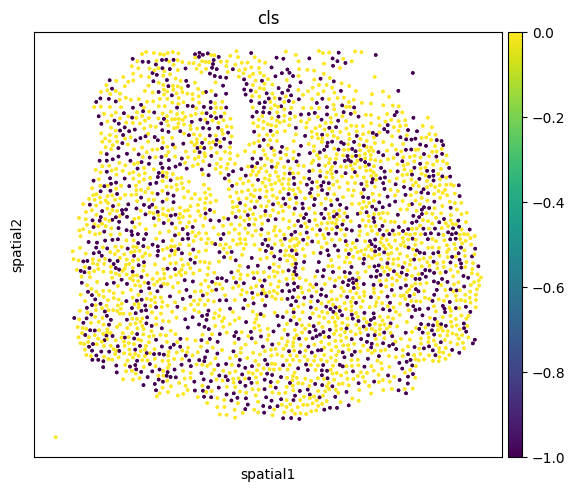

In [262]:
sq.pl.spatial_scatter(
    sub_adata_shh,
    color = ['cls'],
    shape= None,
    size = 10, 
)

In [263]:
import anndata as ad
sub_adata = ad.concat([sub_adata_ctrl, sub_adata_shh], merge = "same")

In [264]:
sub_adata

AnnData object with n_obs × n_vars = 5007 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'sliding_window_assignment', 'globalX', 'globalY', 'obs_names_orig', 'split', 'obs_names', 'shh_cluster', 'cls'
    obsm: 'spatial'

<Figure size 727.8x480 with 0 Axes>

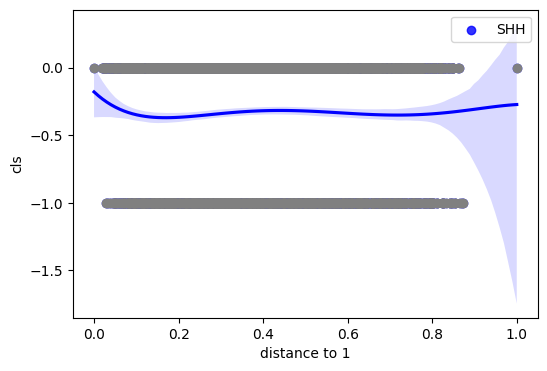

In [15]:
sq.tl.var_by_distance(
    adata=sub_adata,
    groups="1",
    cluster_key="shh_cluster",
    library_key="sample",
    covariates=["condition"],
)
sq.pl.var_by_distance(
    adata=sub_adata,
    design_matrix_key="design_matrix",
    var=['cls'],
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=True,
    figsize=(6, 4),
)

<Figure size 727.8x480 with 0 Axes>

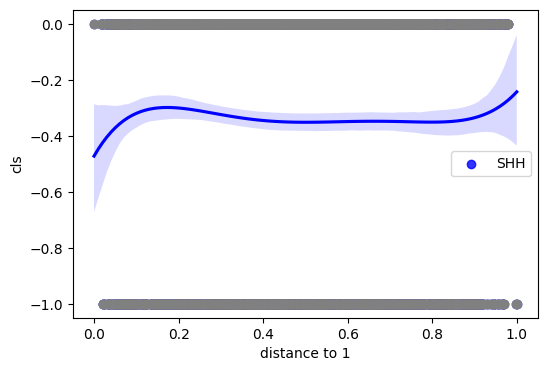

In [266]:
sq.tl.var_by_distance(
    adata=sub_adata_shh,
    groups="1",
    cluster_key="shh_cluster",
    library_key="sample",
    covariates=["condition"],
)
sq.pl.var_by_distance(
    adata=sub_adata_shh,
    design_matrix_key="design_matrix",
    var=['cls'],
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=True,
    figsize=(6, 4),
)

In [91]:
def cell_label_attention(sub_adata, obs_csv, attention_matrix_dict, class_key, library_key = None):
    """Visualizes the normalized attention between cell labels."""
    
    class_names = np.unique(sub_adata.obs[class_key])
    K = len(class_names)
    attn_map = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)
    attn_occurences = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)
    library_list = [str(library_key)]
    if library_key: 
        library_list = np.unique(sub_adata.obs[library_key])
    for library_id in library_list:
        print(library_id)
        #print(np.unique(sub_adata.obs[class_key][sub_adata.obs[library_key]==library_id]))
        # TODO: Incorrect mapping!
        attention_matrix = attention_matrix_dict[library_id]
        filtered_obs_csv = obs_csv[obs_csv['obs_names'].astype(int).isin(attention_matrix.index.astype(int))]
        obs_name_to_cell_type = dict(zip(filtered_obs_csv['obs_names'].astype(str), filtered_obs_csv[class_key]))
        attention_matrix = attention_matrix.rename(index=obs_name_to_cell_type, columns=obs_name_to_cell_type)
        attn_norm = normalized_class_attention(attention_matrix)
        # Add values to attn_map and increment attn_occurences
        attn_map.loc[attn_norm.index, attn_norm.columns] += attn_norm
        attn_occurences.loc[attn_norm.index, attn_norm.columns] += 1

    attn_norm = attn_map/attn_occurences

    return attn_norm

None
0 0
0 1
1 0
1 1


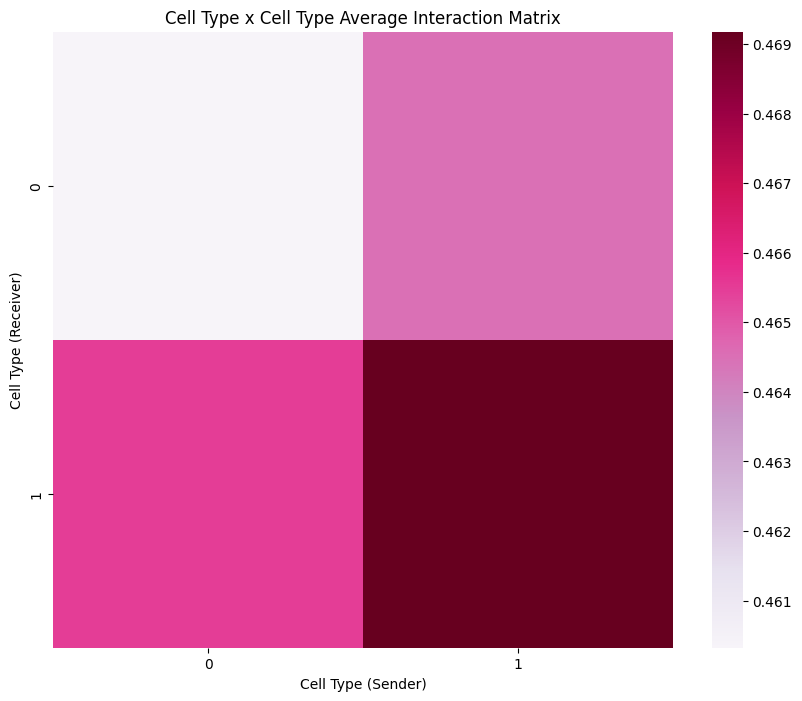

In [98]:
attn_norm_shh = cell_label_attention(sub_adata_shh, obs_csv, attention_matrix_dict_shh, class_key = 'shh_cluster', library_key = None)
plt.figure(figsize=(10, 8))
sns.heatmap(attn_norm_shh, cmap = 'PuRd')
plt.title('Cell Type x Cell Type Average Interaction Matrix')
plt.xlabel('Cell Type (Sender)')
plt.ylabel('Cell Type (Receiver)')
plt.savefig(f'/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/pancreas/heat_map_ND-T1D.png')
plt.show()

In [141]:
import pandas as pd
import numpy as np

def normalized_class_attention(attention_matrix, clamp: float = 0.05, normalize_dim: str = "both"):
    """
    Normalize an attention matrix to either class-level attention or a normalized attention matrix
    of a specified dimensionality.

    Parameters
    ----------
    attention_matrix: Pandas DataFrame
        Matrix of size NxN with column and row indices belonging to either of K classes.
    clamp: float
        Minimum attention value to prevent division by zero or overly small contributions.
    normalize_dim: str
        Dimension for normalization:
        - "row": Normalize to return NxK matrix (attention per row to classes).
        - "column": Normalize to return KxN matrix (attention per class to rows).
        - "both": Normalize to return KxK matrix (attention between classes).

    Returns
    -------
    attn_norm: Pandas DataFrame
        Normalized attention matrix based on `normalize_dim`:
        - NxK if `normalize_dim="row"`.
        - KxN if `normalize_dim="column"`.
        - KxK if `normalize_dim="both"`.
    """
    # Apply normalized attention function
    scores = normalized_attention(attention_matrix, clamp)
    attention_matrix = pd.DataFrame(scores, index=attention_matrix.index, columns=attention_matrix.columns)

    class_names = np.unique(attention_matrix.columns)
    K = len(class_names)

    if normalize_dim == "both":
        # Create a KxK DataFrame
        attn_norm = pd.DataFrame(np.zeros((K, K)), index=class_names, columns=class_names)

        for class_i in class_names:
            for class_j in class_names:
                indices_i = (attention_matrix.index == class_i)
                indices_j = (attention_matrix.columns == class_j)
                norm_value = attention_matrix.loc[indices_i, indices_j].sum() / len(np.argwhere(indices_i == True))
                summed_value = norm_value.sum() / len(np.argwhere(indices_j == True))
                attn_norm.at[class_i, class_j] = summed_value

        return attn_norm

    elif normalize_dim == "row":
        # Create an NxK DataFrame
        attn_norm = pd.DataFrame(0, index=attention_matrix.index, columns=class_names)

        for i, row in attention_matrix.iterrows():
            for class_j in class_names:
                indices_j = (attention_matrix.columns == class_j)
                norm_value = row[indices_j].sum() / len(np.argwhere(indices_j == True))
                attn_norm.at[i, class_j] = norm_value

        return attn_norm

    elif normalize_dim == "column":
        # Create a KxN DataFrame
        attn_norm = pd.DataFrame(0, index=class_names, columns=attention_matrix.columns)

        for class_i in class_names:
            indices_i = (attention_matrix.index == class_i)
            for j in attention_matrix.columns:
                norm_value = attention_matrix.loc[indices_i, j].sum()
                attn_norm.at[class_i, j] = norm_value

        return attn_norm

    else:
        raise ValueError("Invalid value for `normalize_dim`. Choose from 'row', 'column', or 'both'.")



In [142]:
def reindex_attn_matrix(attention_matrix, obs_csv, class_key, dim ):
    filtered_obs_csv = obs_csv[obs_csv['obs_names'].astype(int).isin(attention_matrix.index.astype(int))]
    obs_name_to_cell_type = dict(zip(filtered_obs_csv['obs_names'].astype(str), filtered_obs_csv[class_key]))
    if dim == 'both':
        attention_matrix = attention_matrix.rename(index=obs_name_to_cell_type, columns=obs_name_to_cell_type)
    if dim == 'row':
        attention_matrix = attention_matrix.rename(columns=obs_name_to_cell_type)
    return attention_matrix

In [267]:
attn_matrix = reindex_attn_matrix(attention_matrix_dict_shh['None'], obs_csv, class_key='shh_cluster', dim = 'row')

In [268]:
attn_norm = normalized_class_attention(attn_matrix, clamp=0.05, normalize_dim = "row")

In [269]:
attn_norm

,0,1
0,0.468773,0.518274
2,0.155882,0.129384
3,0.344676,0.473033
4,0.559664,0.519360
5,0.056350,0.022536
...,...,...
3018,0.737676,0.886693
3019,0.662767,0.697001
3020,0.188359,0.220754
3021,0.408697,0.368148


In [270]:
((attn_norm['0'] - attn_norm['1']) > 0).sum()

661

In [271]:
sub_adata_shh.obs['shh_cluster_0'] = attn_norm['0']
sub_adata_shh.obs['shh_cluster_1'] = attn_norm['1']
sub_adata_shh.obs['shh_cluster_diff'] = (attn_norm['0'] - attn_norm['1'])

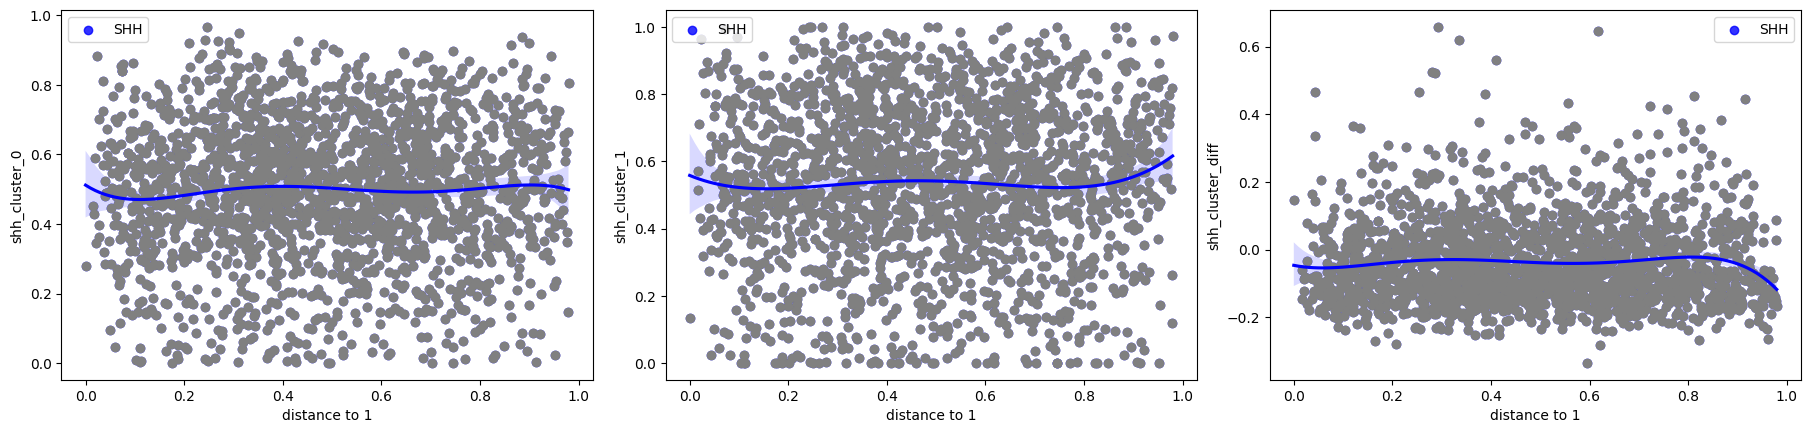

In [272]:
sq.tl.var_by_distance(
    adata=sub_adata_shh,
    groups="1",
    cluster_key="shh_cluster",
    library_key="sample",
    covariates=["condition"],
)
sq.pl.var_by_distance(
    adata=sub_adata_shh,
    design_matrix_key="design_matrix",
    var=['shh_cluster_0', 'shh_cluster_1', 'shh_cluster_diff'],
    anchor_key="1",
    covariate="condition",
    line_palette=["blue", "orange"],
    show_scatter=True,
    figsize=(6, 4),
)

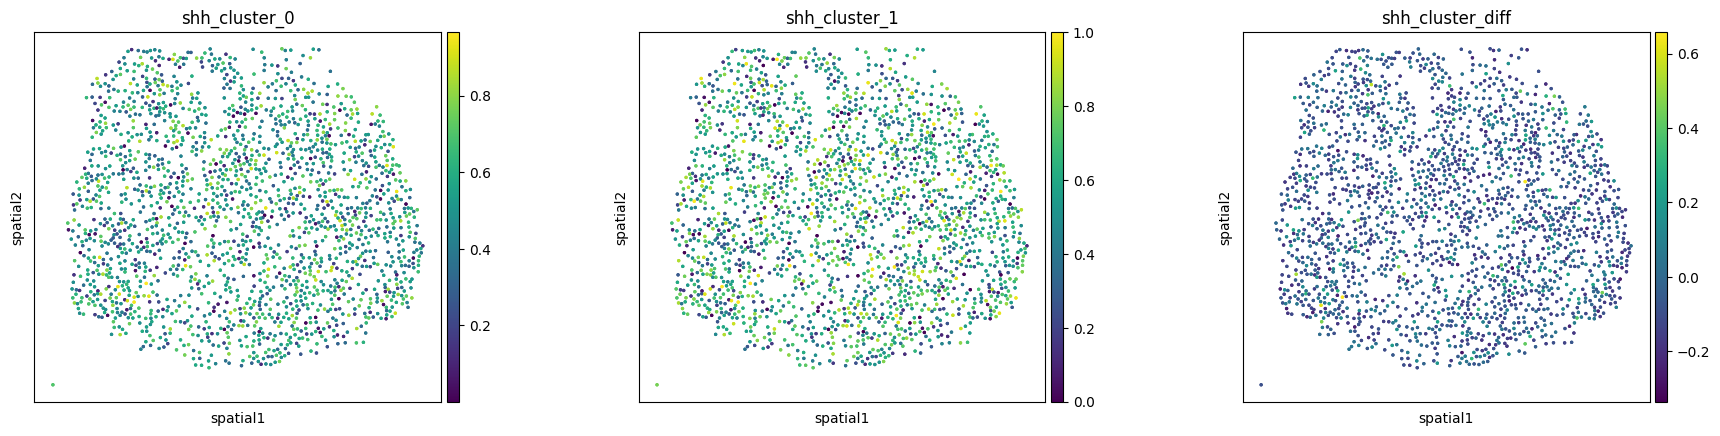

In [273]:
sq.pl.spatial_scatter(
    sub_adata_shh,
    library_key = 'sample',
    #library_id = ['slide1_A2-1', 'slide4_B2-2'],
    color =  ['shh_cluster_0', 'shh_cluster_1', 'shh_cluster_diff'],
    shape= None,
    size = 8, 
)

## GEX prediction

How well can the decoder predict each gene using local and global embeddings?

In [80]:
import torchmetrics

def gex_prediction(sub_adata, embedding_dict, model_transformer):
    results = {
        'R2': {},
        'MSE': {}
    }
    
    gene_names = sub_adata.var_names.tolist()  # Extract gene names as a list
    
    MSE = torchmetrics.MeanSquaredError(num_outputs=len(gene_names))
    R2 = torchmetrics.R2Score(num_outputs=len(gene_names), multioutput = 'raw_values')
    
    print(gene_names)
    
    for library_id, H in embedding_dict.items():
        Y_true = torch.tensor(sub_adata.X.toarray())  # Ensure dense array and convert to tensor
        Y_pred_global = model_transformer.graph_pred_linear(H).squeeze(1)
        if Y_true.shape[0] == Y_pred_global.shape[0] - 1:
            print("Remove cls token")
            Y_pred_global = Y_pred_global[1:,:]
    
        assert Y_true.shape == Y_pred_global.shape
    
        # Compute Gaussian NLL Loss
        r2 = R2(Y_true, Y_pred_global)
    
        # Compute MSE Loss
        mse = MSE(Y_true, Y_pred_global)
    
        # Update results dictionary
        results['R2'].update({gene: loss for gene, loss in zip(gene_names, r2)})
        results['MSE'].update({gene: loss for gene, loss in zip(gene_names, mse)})
    
    # Sort the results by decreasing loss values
    results['R2'] = dict(sorted(results['R2'].items(), key=lambda item: item[1], reverse=True))
    results['MSE'] = dict(sorted(results['MSE'].items(), key=lambda item: item[1], reverse=True))
    
    # Example: Inspect top 10 genes with the highest loss for each loss type
    top_n = 20
    print("Top genes by R2:")
    for gene, loss in list(results['R2'].items())[:top_n]:
        print(f"{gene}: {loss}")
    
    print("\nTop genes by MSE:")
    for gene, loss in list(results['MSE'].items())[:top_n]:
        print(f"{gene}: {loss}")

    return results

In [93]:
results_global = gex_prediction(sub_adata_ctrl, trans_out_dict_ctrl, model_transformer_gex)

['AC129492.1', 'AGO2', 'AIF1', 'ALDH1L1', 'AQP4', 'ARC', 'ARG1', 'BCL11B', 'BMP4', 'CALB1', 'CDR1', 'CHAT', 'CHPF2', 'Circ.CDR1', 'Circ.RMST', 'CUL3', 'CUX2', 'DBX1', 'DBX2', 'DLX2', 'EOMES', 'EYA4', 'FOS', 'FOSB', 'FOSL2', 'FOXA1', 'FOXA2', 'FOXO6', 'FZD10', 'GAD1', 'GLI1', 'GLI2', 'GLI3', 'GRID2', 'HES6', 'HEY1', 'HHIP', 'HOPX', 'HPRT1', 'IRX3', 'ISL1', 'JUN', 'JUNB', 'KLF13', 'KLF4', 'LUM', 'MAP2', 'MNX1', 'MOG', 'MSX2', 'MYRIP', 'NEUROD1', 'NEUROG2', 'NKX2.1', 'NKX2.2', 'NKX6.1', 'NKX6.2', 'NR4A2', 'NR4A3', 'OIP5.AS1', 'OLIG1', 'OLIG2', 'OTP', 'OTX2', 'PAX6', 'PAX7', 'PER2', 'PER3', 'POLR1B', 'PROM1', 'PTCH1', 'PTPRZ1', 'SATB2', 'SHH', 'SIX6', 'SMO', 'SNCA', 'SOX2', 'STMN2', 'TBP', 'TBR1', 'TUBB1', 'TUBB3', 'VAMP2', 'ZNF609', 'ZSWIM8', 'FOXG1', 'TREM2']
Remove cls token
Top genes by R2:
NKX2.1: -0.0014537572860717773
TBR1: -0.24281680583953857
NKX6.2: -0.5213057994842529
OLIG1: -0.7006323337554932
EYA4: -1.0486631393432617
SIX6: -1.106499433517456
OLIG2: -1.5182795524597168
EOMES: 

In [94]:
list(results_global['R2'].keys())[:5]

['NKX2.1', 'TBR1', 'NKX6.2', 'OLIG1', 'EYA4']

In [91]:
results_local = gex_prediction(sub_adata_ctrl, trans_in_dict_ctrl, model_transformer_gex)

['AC129492.1', 'AGO2', 'AIF1', 'ALDH1L1', 'AQP4', 'ARC', 'ARG1', 'BCL11B', 'BMP4', 'CALB1', 'CDR1', 'CHAT', 'CHPF2', 'Circ.CDR1', 'Circ.RMST', 'CUL3', 'CUX2', 'DBX1', 'DBX2', 'DLX2', 'EOMES', 'EYA4', 'FOS', 'FOSB', 'FOSL2', 'FOXA1', 'FOXA2', 'FOXO6', 'FZD10', 'GAD1', 'GLI1', 'GLI2', 'GLI3', 'GRID2', 'HES6', 'HEY1', 'HHIP', 'HOPX', 'HPRT1', 'IRX3', 'ISL1', 'JUN', 'JUNB', 'KLF13', 'KLF4', 'LUM', 'MAP2', 'MNX1', 'MOG', 'MSX2', 'MYRIP', 'NEUROD1', 'NEUROG2', 'NKX2.1', 'NKX2.2', 'NKX6.1', 'NKX6.2', 'NR4A2', 'NR4A3', 'OIP5.AS1', 'OLIG1', 'OLIG2', 'OTP', 'OTX2', 'PAX6', 'PAX7', 'PER2', 'PER3', 'POLR1B', 'PROM1', 'PTCH1', 'PTPRZ1', 'SATB2', 'SHH', 'SIX6', 'SMO', 'SNCA', 'SOX2', 'STMN2', 'TBP', 'TBR1', 'TUBB1', 'TUBB3', 'VAMP2', 'ZNF609', 'ZSWIM8', 'FOXG1', 'TREM2']
Top genes by R2:
KLF13: 0.3914240598678589
CUX2: 0.23290610313415527
ARG1: -0.009396195411682129
SATB2: -0.0181427001953125
MNX1: -0.0987621545791626
CHPF2: -0.19753038883209229
NKX2.1: -0.27620232105255127
NKX2.2: -0.36493253707885

In [92]:
list(results_local['R2'].keys())[:5]

['KLF13', 'CUX2', 'ARG1', 'SATB2', 'MNX1']

In [ ]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold

def compute_r2_per_gene(X_train, y_train, X_test, y_test, alpha=1.0):
    """
    Compute R^2 for each gene using Ridge regression.
    
    Parameters:
    - X_train, X_test: Embeddings (n_samples x n_features)
    - y_train, y_test: Gene expression (n_samples x n_genes)
    - alpha: Regularization strength for Ridge regression

    Returns:
    - r2_per_gene: Array of R^2 scores for each gene
    """
    n_genes = y_train.shape[1]
    r2_per_gene = []
    
    for gene_idx in range(n_genes):
        # Select the gene to predict
        y_train_gene = y_train[:, gene_idx]
        y_test_gene = y_test[:, gene_idx]
        
        # Train Ridge regression model
        model = Ridge(alpha=alpha)
        model.fit(X_train, y_train_gene)
        y_pred_gene = model.predict(X_test)
        
        # Compute R^2 for the gene
        r2_gene = r2_score(y_test_gene, y_pred_gene)
        r2_per_gene.append(r2_gene)
    
    return np.array(r2_per_gene)

def analyze_per_gene_variance(Z_GNN, Z_Transformer, Y, alpha=1.0, cv_splits=5, top_genes:int = 5):
    """
    Analyze variance explained per gene and find top genes.
    
    Parameters:
    - Z_GNN: Embeddings from GNN (n_samples x n_features)
    - Z_Transformer: Embeddings from Transformer (n_samples x n_features)
    - Y: Target gene expressions (n_samples x n_genes)
    - alpha: Regularization strength for Ridge regression
    - cv_splits: Number of cross-validation splits

    Returns:
    - top_genes_gnn: Top genes based on R^2 for Z_GNN
    - top_genes_transformer: Top genes based on R^2 for Z_Transformer
    - r2_gnn_mean: Mean R^2 scores for Z_GNN per gene
    - r2_transformer_mean: Mean R^2 scores for Z_Transformer per gene
    """
    n_genes = Y.shape[1]
    r2_gnn_all = np.zeros((cv_splits, n_genes))
    r2_transformer_all = np.zeros((cv_splits, n_genes))
    
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(Y)):
        # Split data
        Z_GNN_train, Z_GNN_test = Z_GNN[train_idx], Z_GNN[test_idx]
        Z_Transformer_train, Z_Transformer_test = Z_Transformer[train_idx], Z_Transformer[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        
        # Compute R^2 per gene for GNN
        r2_gnn_all[fold_idx, :] = compute_r2_per_gene(Z_GNN_train, Y_train, Z_GNN_test, Y_test, alpha)
        
        # Compute R^2 per gene for Transformer
        r2_transformer_all[fold_idx, :] = compute_r2_per_gene(Z_Transformer_train, Y_train, Z_Transformer_test, Y_test, alpha)
    
    # Mean R^2 across folds
    r2_gnn_mean = r2_gnn_all.mean(axis=0)
    r2_transformer_mean = r2_transformer_all.mean(axis=0)
    
    # Identify top genes
    top_genes_gnn = np.argsort(-r2_gnn_mean)[:top_genes]  # Top 5 genes for GNN
    top_genes_transformer = np.argsort(-r2_transformer_mean)[:top_genes]  # Top 5 genes for Transformer
    
    return top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean

In [ ]:
Z_local_ctrl = trans_in_dict_ctrl[None].detach().numpy().squeeze(1)
Z_local_shh = trans_in_dict_shh[None].detach().numpy().squeeze(1)
Z_local.shape

In [ ]:
Z_global_ctrl = trans_out_dict_ctrl[None].detach().numpy().squeeze(1)
Z_global_shh = trans_out_dict_shh[None].detach().numpy().squeeze(1)
Z_global.shape

In [ ]:
# Compute per-gene R^2 and find top-performing genes
top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean = analyze_per_gene_variance(
    Z_local_ctrl, Z_global_ctrl, sub_adata_ctrl.X.toarray(), alpha=1.0, cv_splits=5, top_genes = 10
)

# Print results
print("Top genes for GNN (indices):", sub_adata_ctrl.var_names[top_genes_gnn])
print("Top genes for Transformer (indices):", sub_adata_ctrl.var_names[top_genes_transformer])
print("R^2 mean for GNN:", r2_gnn_mean)
print("R^2 mean for Transformer:", r2_transformer_mean)

In [ ]:
# Compute per-gene R^2 and find top-performing genes
top_genes_gnn, top_genes_transformer, r2_gnn_mean, r2_transformer_mean = analyze_per_gene_variance(
    Z_local_shh, Z_global_shh, sub_adata_shh.X.toarray(), alpha=1.0, cv_splits=5, top_genes = 10
)

# Print results
print("Top genes for GNN (indices):", sub_adata_shh.var_names[top_genes_gnn])
print("Top genes for Transformer (indices):", sub_adata_shh.var_names[top_genes_transformer])
print("R^2 mean for GNN:", r2_gnn_mean)
print("R^2 mean for Transformer:", r2_transformer_mean)

In [87]:
def local_global_variance_composition(r2_gnn_mean, r2_transformer_mean, var_names, n_genes=10):
    """
    Plot normalized variance composition for the top `n_genes` genes with the highest variance explained.
    
    Parameters:
    - r2_gnn_mean: Array of variance explained by the GNN.
    - r2_transformer_mean: Array of variance explained by the Transformer.
    - var_names: List of gene names corresponding to the variance arrays.
    - n_genes: Number of top genes to plot based on total explained variance.
    """
    # Compute unexplained variance (1 - max variance explained by GNN or Transformer)
    unexplained_variance = 1 - np.maximum(r2_gnn_mean, r2_transformer_mean)
    
    # Total variance normalization (Local + Global + Noise)
    total_variance = r2_gnn_mean + r2_transformer_mean + unexplained_variance
    
    # Normalize variances
    normalized_local = r2_gnn_mean / total_variance
    normalized_global = r2_transformer_mean / total_variance
    normalized_noise = unexplained_variance / total_variance
    
    # Rank genes by total explained variance (GNN + Transformer)
    explained_variance = r2_gnn_mean + r2_transformer_mean
    top_indices = np.argsort(-explained_variance)[:n_genes]  # Get indices of top genes
    
    # Select top genes and their corresponding variances
    top_local = normalized_local[top_indices]
    top_global = normalized_global[top_indices]
    top_noise = normalized_noise[top_indices]
    top_gene_names = [var_names[i] for i in top_indices]
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(top_gene_names))
    
    # Plot normalized variances
    ax.bar(x, top_local, color='green', label='GNN (Local)')
    ax.bar(x, top_global, bottom=top_local, color='blue', label='Transformer (Global)')
    ax.bar(x, top_noise, bottom=top_local + top_global, color='gray', label='Unexplained')
    
    # Customize plot
    ax.set_xticks(x)
    ax.set_xticklabels(top_gene_names, rotation=45, ha='right')
    ax.set_ylabel('Normalized Variance Explained')
    ax.set_title(f'Normalized Variance Explained for Top {n_genes} Genes')
    ax.set_ylim(0, 1)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

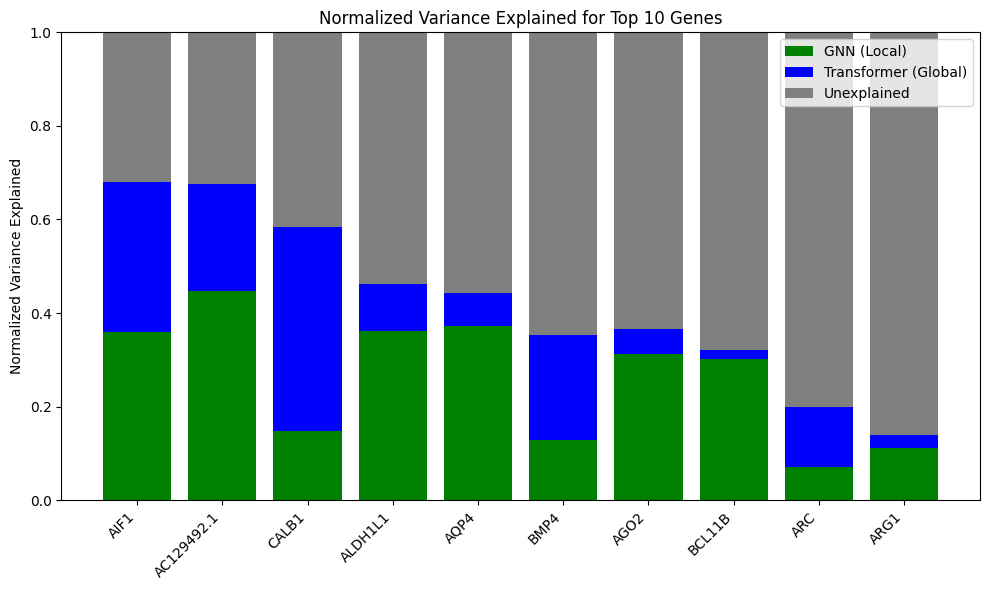

In [88]:
local_global_variance_composition(r2_gnn_mean, r2_transformer_mean, sub_adata_shh.var_names, n_genes=10)

In [ ]:
sq.tl.var_by_distance(
    adata=adata,
    groups="Epithelial",
    cluster_key="Sample",
    library_key="library_id",
    covariates=["category", "donor"],
)